In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
alpha = cv2.imread("ALPHABETS.jpg")

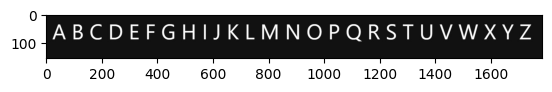

In [5]:
plt.imshow(alpha,cmap='gray')

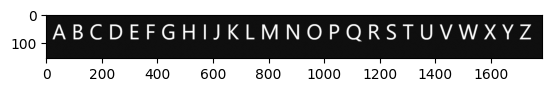

In [7]:
alpha_gray = cv2.cvtColor(alpha,cv2.COLOR_BGR2GRAY)
plt.imshow(alpha_gray,cmap='gray')

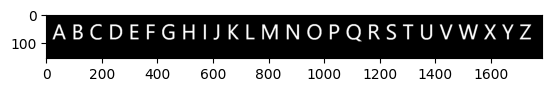

In [9]:
_,alpha_threshold = cv2.threshold(
    alpha_gray,
    127,
    255,
    cv2.THRESH_BINARY
)
plt.imshow(alpha_threshold,cmap='gray')

In [10]:
alpha_contours,hierarcy = cv2.findContours(
    alpha_threshold,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)
print(len(alpha_contours))

26


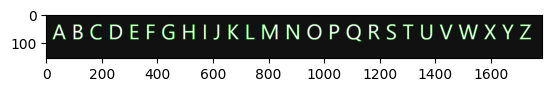

In [12]:
drawing_image = alpha.copy()
cv2.drawContours(
    drawing_image,
    alpha_contours,
    -1,
    (0,255,0),
    1
)
plt.imshow(drawing_image)

In [74]:
test = cv2.imread('hello_world.jpg')

In [75]:
test.shape

(350, 350, 3)

In [76]:
gray_test = cv2.cvtColor(test,cv2.COLOR_BGR2GRAY)

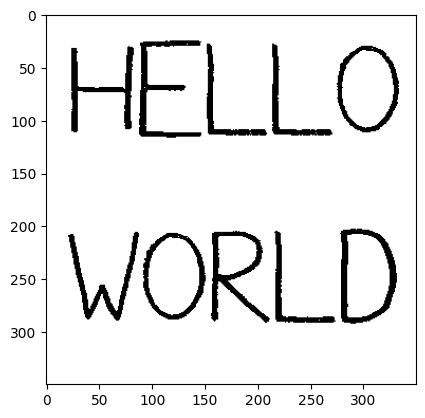

In [77]:
_,test_threshold =cv2.threshold(
    gray_test,
    110,
    255,
    cv2.THRESH_BINARY
)
plt.imshow(test_threshold,cmap='gray')

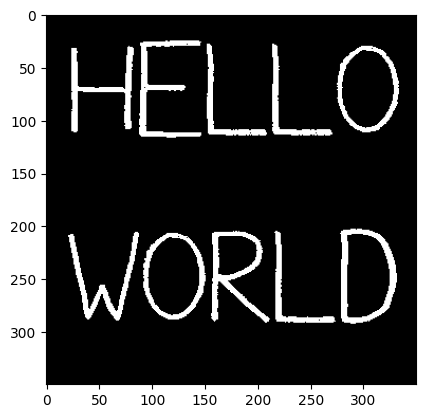

In [78]:
plt.imshow(cv2.bitwise_not(test_threshold),cmap='gray')

In [79]:
test_contours, hierarcy = cv2.findContours(
    cv2.bitwise_not(test_threshold),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)
print(len(test_contours))

10


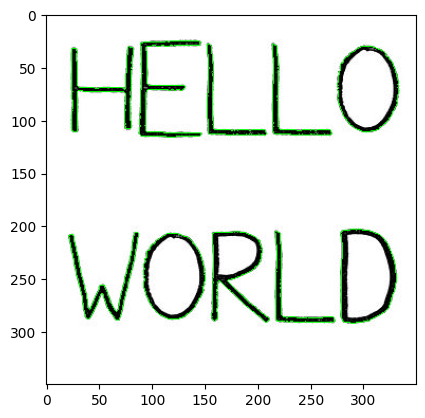

In [81]:
test_drawing_image = test.copy()
cv2.drawContours(
    test_drawing_image,
    test_contours,
    -1,
    (0,255,0),
    1
)
plt.imshow(test_drawing_image)

In [87]:
recognized_text = ""

for test_contour in test_contours:

    min_score = float("inf")
    predicted_letter = ""

    for i in range(len(alpha_contours)):

        score = cv2.matchShapes(
            test_contour,
            alpha_contours[i],
            cv2.CONTOURS_MATCH_I1,
            0.0
        )

        if score < min_score:
            min_score = score
            predicted_letter = chr(ord('A') + i)

    recognized_text += predicted_letter

print("Recognized text:", recognized_text)

Recognized text: SXXHTSXXXX


Contour-based shape matching using Hu Moments was evaluated for handwritten English character recognition. Although the method is invariant to certain transformations such as translation and scaling, it did not provide reliable character-level discrimination. In particular, visually similar handwritten characters could produce lower Hu-moment difference scores for incorrect templates. The method also loses important internal character structure when only external contours are considered.